In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
path = r"C:\Users\13926\Atlantic-Project\AmesHousingClean.csv"
df = pd.read_csv(path)

In [ ]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [188]:
# Scale using Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [189]:
# Fit the data to Linear Regression and see the result
lin_regressor = LinearRegression()
lin_regressor.fit(X_train_scaled, y_train)
y_train_pred_lin = lin_regressor.predict(X_train_scaled)
y_pred_lin = lin_regressor.predict(X_test_scaled)

mae_train_lin = mean_absolute_error(y_train, y_train_pred_lin)
mae_test_lin = mean_absolute_error(y_test, y_pred_lin)
mape_train_lin = mean_absolute_percentage_error(y_train, y_train_pred_lin) * 100
mape_test_lin = mean_absolute_percentage_error(y_test, y_pred_lin) * 100
r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_pred_lin)

print(f'MAE (training): {mae_train_lin}')
print(f'MAE (testing): {mae_test_lin}')
print(f'MAPE (training): {mape_train_lin:.4f}%')
print(f'MAPE (testing): {mape_test_lin:.4f}%')
print(f'R-Squared score (training): {r2_train_lin}')
print(f'R-Squared score (testing): {r2_test_lin}')

MAE (training): 23516.761340961348
MAE (testing): 22597.888651041307
MAPE (training): 13.5300%
MAPE (testing): 12.8434%
R-Squared score (training): 0.7922998199813032
R-Squared score (testing): 0.8194873194358329


In [190]:
# Fit with KNN Regressor
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X_train_scaled, y_train)
y_train_pred_knn = knn_regressor.predict(X_train_scaled)
y_pred_knn = knn_regressor.predict(X_test_scaled)

mae_test_knn_default = mean_absolute_error(y_test, y_pred_knn)
mape_test_knn_default = mean_absolute_percentage_error(y_test, y_pred_knn) * 100
r2_train_knn_default = r2_score(y_train, y_train_pred_knn)
r2_test_knn_default = r2_score(y_test, y_pred_knn)

print(f'MAE (testing): {mae_test_knn_default}')
print(f'MAPE (testing): {mape_test_knn_default:.4f}%')
print(f'R-Squared score (training): {r2_train_knn_default}')
print(f'R-Squared score (testing): {r2_test_knn_default}')

MAE (testing): 20080.605555555554
MAPE (testing): 11.3524%
R-Squared score (training): 0.9003025321991948
R-Squared score (testing): 0.8498950853524728


In [191]:
# Fine-tune KNN Regressor with grid search
param_grid_knn = {'n_neighbors': range(1, 31, 2),
                  'weights': ['uniform', 'distance'],
                  'metric': ['euclidean', 'manhattan', 'minkowski'], }
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='neg_mean_absolute_error', n_jobs=-2)
grid_knn.fit(X_train_scaled, y_train)
print(grid_knn.best_params_)

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [192]:
# Fit the fine-tuned KNN Regressor
knn_regressor = KNeighborsRegressor(**grid_knn.best_params_)
knn_regressor.fit(X_train_scaled, y_train)
y_train_pred_knn = knn_regressor.predict(X_train_scaled)
y_pred_knn = knn_regressor.predict(X_test_scaled)

mae_train_knn_best = mean_absolute_error(y_train, y_train_pred_knn)
mae_test_knn_best = mean_absolute_error(y_test, y_pred_knn)
mape_train_knn_best = mean_absolute_percentage_error(y_train, y_train_pred_knn) * 100
mape_test_knn_best = mean_absolute_percentage_error(y_test, y_pred_knn) * 100
r2_train_knn_best = r2_score(y_train, y_train_pred_knn)
r2_test_knn_best = r2_score(y_test, y_pred_knn)

print(f'MAE (training): {mae_train_knn_best}')
print(f'MAE (testing): {mae_test_knn_best}')
print(f'MAPE (training): {mape_train_knn_best:.4f}%')
print(f'MAPE (testing): {mape_test_knn_best:.4f}%')
print(f'R-Squared score (training): {r2_train_knn_best}')
print(f'R-Squared score (testing): {r2_test_knn_best}')

MAE (training): 48.74907407407407
MAE (testing): 18952.85366930951
MAPE (training): 0.0328%
MAPE (testing): 10.4620%
R-Squared score (training): 0.9999534711920957
R-Squared score (testing): 0.8519586420191667


In [193]:
# Try with Random Forest Regressor
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train_scaled, y_train)
y_train_pred_rf = rf_regressor.predict(X_train_scaled)
y_pred_rf = rf_regressor.predict(X_test_scaled)

mae_test_rf_default = mean_absolute_error(y_test, y_pred_rf)
mape_test_rf_default = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
r2_train_rf_default = r2_score(y_train, y_train_pred_rf)
r2_test_rf_default = r2_score(y_test, y_pred_rf)

print(f'MAE (testing): {mae_test_rf_default}')
print(f'MAPE (testing): {mape_test_rf_default:.4f}%')
print(f'R-Squared score (training): {r2_train_rf_default}')
print(f'R-Squared score (testing): {r2_test_rf_default}')

MAE (testing): 17692.713801807757
MAPE (testing): 10.2004%
R-Squared score (training): 0.9824072020187594
R-Squared score (testing): 0.8729763504480719


In [194]:
# Also do grid search on Random Forest Regressor
"""
param_grid = {
    'n_estimators': [np.random.randint(100, 300), np.random.randint(100, 300)],
    'max_features': ['sqrt', 'auto'],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
}

grid_rf = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, scoring='neg_mean_absolute_error', cv=5)
grid_rf.fit(X_train_scaled, y_train)
print('Best Parameters', grid_rf.best_params_)
"""

"\nparam_grid = {\n    'n_estimators': [np.random.randint(100, 300), np.random.randint(100, 300)],\n    'max_features': ['sqrt', 'auto'],\n    'max_depth': [10, 20, 30, None],\n    'min_samples_leaf': [1, 2, 4],\n    'min_samples_split': [2, 5, 10],\n}\n\ngrid_rf = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, scoring='neg_mean_absolute_error', cv=5)\ngrid_rf.fit(X_train_scaled, y_train)\nprint('Best Parameters', grid_rf.best_params_)\n"

In [195]:
# print('Best Parameters', grid_rf.best_params_)

In [196]:
"""
n_estimators=215,
                                     max_depth=9,
                                     max_features='sqrt',
                                     min_samples_leaf=1,
                                     min_samples_split=2,

"""

"\nn_estimators=215,\n                                     max_depth=9,\n                                     max_features='sqrt',\n                                     min_samples_leaf=1,\n                                     min_samples_split=2,\n\n"

In [211]:
# Fit the fine-tuned model
rf_regressor_tuned = RandomForestRegressor(n_estimators=201,
                                     max_depth=9,
                                     max_features='sqrt',
                                     min_samples_leaf=1,
                                     min_samples_split=2,)
rf_regressor_tuned.fit(X_train_scaled, y_train)
y_train_pred_rf_tuned = rf_regressor_tuned.predict(X_train_scaled)
y_pred_rf_tuned = rf_regressor_tuned.predict(X_test_scaled)

mae_train_rf_best = mean_absolute_error(y_train, y_train_pred_rf_tuned)
mae_test_rf_best = mean_absolute_error(y_test, y_pred_rf_tuned)
mape_train_rf_best = mean_absolute_percentage_error(y_train, y_train_pred_rf_tuned) * 100
mape_test_rf_best = mean_absolute_percentage_error(y_test, y_pred_rf_tuned) * 100
r2_train_rf_best = r2_score(y_train, y_train_pred_rf_tuned)
r2_test_rf_best = r2_score(y_test, y_pred_rf_tuned)

print(f'MAE (training): {mae_train_rf_best}')
print(f'MAE (testing): {mae_test_rf_best}')
print(f'MAPE (training): {mape_train_rf_best:.4f}%')
print(f'MAPE (testing): {mape_test_rf_best:.4f}%')
print(f'R-Squared score (training): {r2_train_rf_best}')
print(f'R-Squared score (testing): {r2_test_rf_best}')

MAE (training): 11812.169268537553
MAE (testing): 16720.60284264307
MAPE (training): 7.0736%
MAPE (testing): 9.6561%
R-Squared score (training): 0.9591362127308873
R-Squared score (testing): 0.8870825085925884


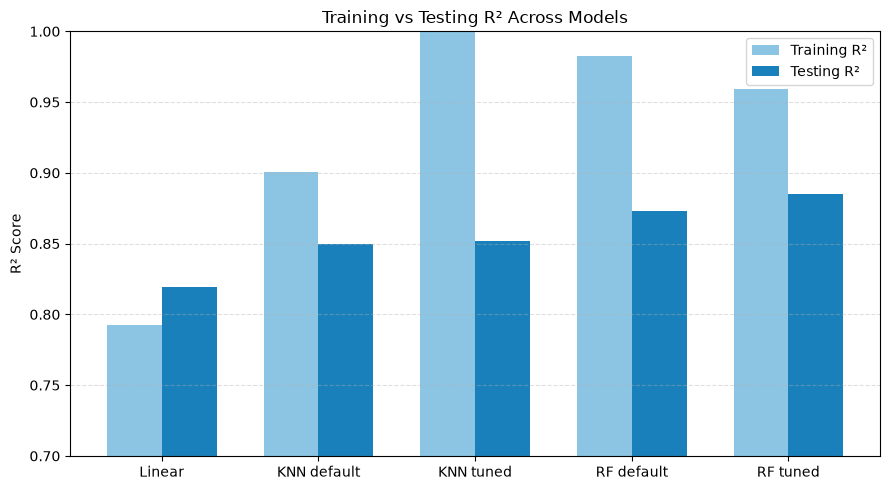

In [198]:
models = ['Linear', 'KNN default', 'KNN tuned', 'RF default', 'RF tuned']
train_r2 = [r2_train_lin, r2_train_knn_default, r2_train_knn_best, r2_train_rf_default, r2_train_rf_best]
test_r2 = [r2_test_lin, r2_test_knn_default, r2_test_knn_best, r2_test_rf_default, r2_test_rf_best]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, train_r2, width, label='Training R²', color='#8cc5e3')
ax.bar(x + width/2, test_r2, width, label='Testing R²', color='#1a80bb')
ax.set_ylabel('R² Score')
ax.set_title('Training vs Testing R² Across Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.70, 1.00)
plt.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [199]:
# The data is outdated so we need an inflation factor so that the model also works when dealing with new data
inflation_factor = 1.867

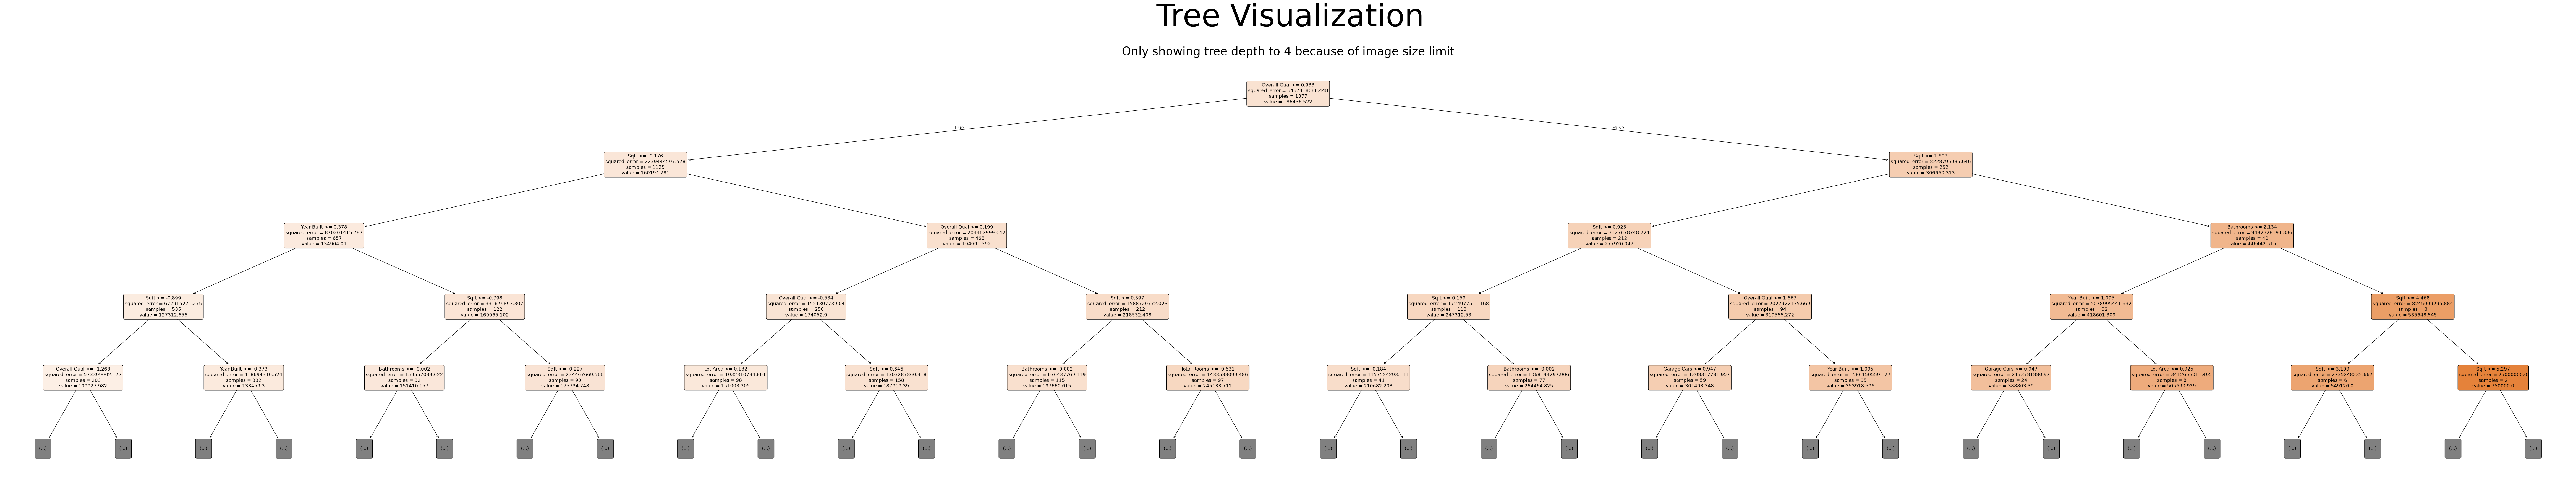

In [200]:
tree = rf_regressor.estimators_[0]
plt.figure(figsize=(120, 20))
plot_tree(tree,
          max_depth=4,
          feature_names=X_train.columns,
          filled=True,
          rounded=True,
          fontsize=12)
plt.suptitle('         Tree Visualization', fontsize=80)
plt.title('Only showing tree depth to 4 because of image size limit', fontsize=30)
plt.show()


In [201]:
import joblib

In [202]:
joblib.dump(rf_regressor_tuned, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
# joblib.dump(neighborhood_avg, 'neighborhood_avg.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

def predict_new_data(new_df):
    model = joblib.load('rf_model.pkl')
    scaler = joblib.load('scaler.pkl')
    # neighborhood_avg = joblib.load('neighborhood_avg.pkl')
    feature_columns = joblib.load('feature_columns.pkl')

    df = new_df.copy()

    # df['Neighborhood_encoded'] = df['Neighborhood'].map(neighborhood_avg)
    # df['Neighborhood_encoded'] = df['Neighborhood_encoded'].fillna(neighborhood_avg.mean())
    # df = df.drop(columns='Neighborhood')

    df = df[feature_columns]

    df_scaled = scaler.transform(df)

    return model.predict(df_scaled) * inflation_factor # Multiply the predicted price by the inflation factor to adjust for inflation

In [203]:
X_train.columns

Index(['Overall Qual', 'Lot Area', 'Sqft', 'Has Basement', 'Garage Cars',
       'Year Built', 'Total Rooms', 'Bedrooms', 'Bathrooms', 'Fireplaces'],
      dtype='str')

In [204]:
new_data = pd.DataFrame({
    'Overall Qual': [np.nan],
    'Lot Area': [14209],
    'Sqft': [2875],
    'Has Basement': [1],
    'Garage Cars': [2],
    'Year Built': [2002],
    'Total Rooms': [18],
    'Bedrooms': [4],
    'Bathrooms': [4],
    'Fireplaces': [1],
})

prediction = predict_new_data(new_data)
print(f'Predicted price: {prediction.astype(int)}')

Predicted price: [404182]


In [205]:
new_data = pd.DataFrame({
    'Overall Qual': [np.nan],
    'Lot Area': [2405],
    'Sqft': [1748],
    'Has Basement': [1],
    'Garage Cars': [2],
    'Year Built': [2019],
    'Total Rooms': [14],
    'Bedrooms': [4],
    'Bathrooms': [4],
    'Fireplaces': [np.nan],
})

prediction = predict_new_data(new_data)
print(f'Predicted price: {prediction.astype(int)}')

Predicted price: [326802]


In [206]:
new_data = pd.DataFrame({
    'Overall Qual': [np.nan],
    'Lot Area': [216058],
    'Sqft': [5949],
    'Has Basement': [1],
    'Garage Cars': [3],
    'Year Built': [1996],
    'Total Rooms': [21],
    'Bedrooms': [8],
    'Bathrooms': [6],
    'Fireplaces': [3],
})

prediction = predict_new_data(new_data)
print(f'Predicted price: {prediction.astype(int)}')

Predicted price: [755876]
